<a href="https://colab.research.google.com/github/JourdynLuv/JourdynLuv/blob/main/Titanic_Project_Razai_Khalid.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

df = pd.read_csv('titanic_passengers.csv')

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


/tmp/ipykernel_1355/530273106.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=df, palette='Set2')


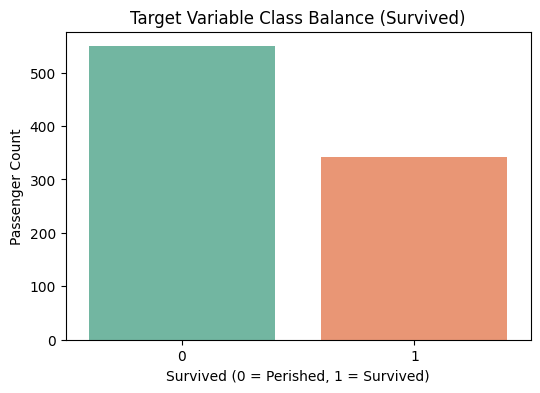

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))

sns.countplot(x='Survived', data=df, palette='Set2')

plt.title('Target Variable Class Balance (Survived)')
plt.xlabel('Survived (0 = Perished, 1 = Survived)')
plt.ylabel('Passenger Count')

plt.show()

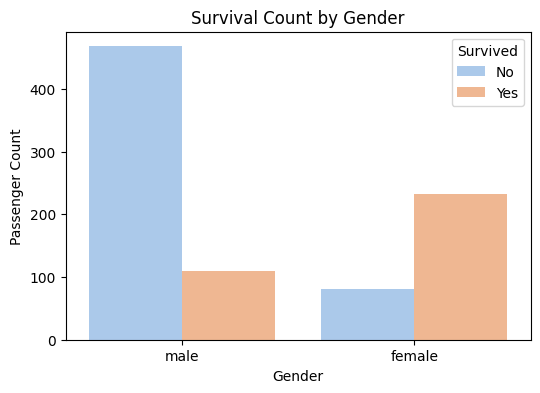

In [3]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Sex', hue='Survived', data=df, palette='pastel')

plt.title('Survival Count by Gender')
plt.xlabel('Gender')
plt.ylabel('Passenger Count')
plt.legend(title='Survived', labels=['No', 'Yes'])

plt.show()

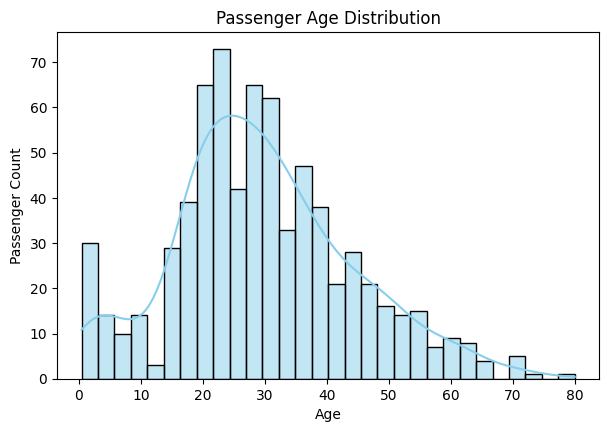

In [4]:
plt.figure(figsize=(7, 4.5))

sns.histplot(df['Age'].dropna(), kde=True, color='skyblue', bins=30)

plt.title('Passenger Age Distribution')
plt.xlabel('Age')
plt.ylabel('Passenger Count')

plt.show()

In [5]:
print("Missing ages before:", df['Age'].isnull().sum())

median_age = df['Age'].median()
print("The median age is:", median_age)

df['Age'] = df['Age'].fillna(median_age)

print("Missing ages after:", df['Age'].isnull().sum())

Missing ages before: 177
The median age is: 28.0
Missing ages after: 0


In [6]:
import numpy as np

df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

df['IsAlone'] = np.where(df['FamilySize'] == 1, 1, 0)

df[['Name', 'SibSp', 'Parch', 'FamilySize', 'IsAlone']].head()

,Name,SibSp,Parch,FamilySize,IsAlone
0,"Braund, Mr. Owen Harris",1,0,2,0
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,0,2,0
2,"Heikkinen, Miss. Laina",0,0,1,1
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,0,2,0
4,"Allen, Mr. William Henry",0,0,1,1


In [8]:
from sklearn.model_selection import train_test_split

df_encoded = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)

X = df_encoded.drop(columns=['Survived', 'PassengerId', 'Name', 'Ticket', 'Cabin'])
y = df_encoded['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data successfully split!")
print(f"Training samples: {X_train.shape[0]} | Testing samples: {X_test.shape[0]}")
print("\nFinal list of features going into the AI model:")
print(list(X.columns))

Data successfully split!
Training samples: 712 | Testing samples: 179

Final list of features going into the AI model:
['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone', 'Sex_male', 'Embarked_Q', 'Embarked_S']


In [9]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, random_state=42)

model.fit(X_train, y_train)

train_accuracy = model.score(X_train, y_train)
test_accuracy = model.score(X_test, y_test)

print(f"Model Training Complete!")
print(f"Training Accuracy Score: {train_accuracy * 100:.2%}")
print(f"Testing Accuracy Score: {test_accuracy * 100:.2%}")

Model Training Complete!
Training Accuracy Score: 8005.62%
Testing Accuracy Score: 7988.83%


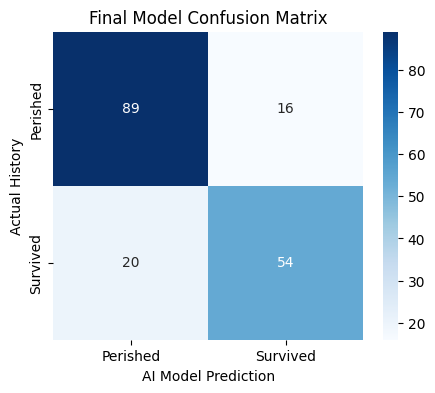

In [10]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Perished', 'Survived'],
            yticklabels=['Perished', 'Survived'])

plt.title('Final Model Confusion Matrix')
plt.ylabel('Actual History')
plt.xlabel('AI Model Prediction')
plt.show()

/tmp/ipykernel_1355/2183317704.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=df, palette='Set2')


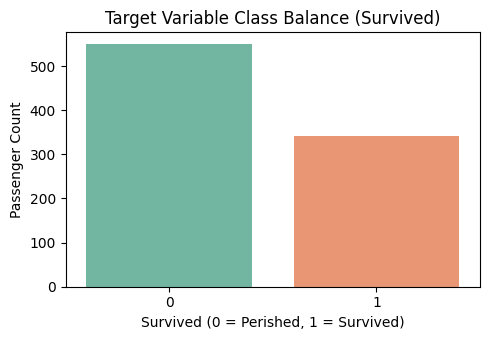

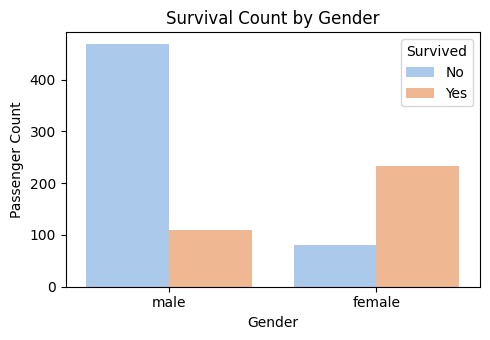

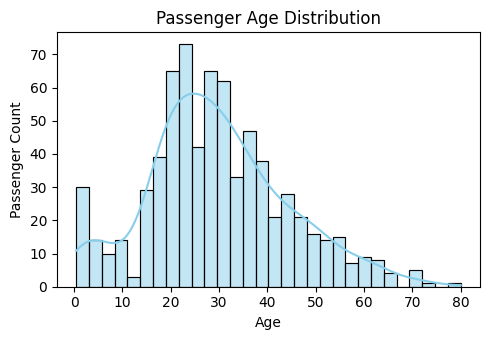

Logistic Regression Best Grid Score: 79.91%
Random Forest Best Grid Score: 82.86%

Selected Best Estimator: RandomForestClassifier(max_depth=5, random_state=42)

Final Training Accuracy Score: 86.10%
Final Testing Accuracy Score: 80.45%

--- Final Classification Report ---
              precision    recall  f1-score   support

           0       0.80      0.89      0.84       105
           1       0.81      0.69      0.74        74

    accuracy                           0.80       179
   macro avg       0.81      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



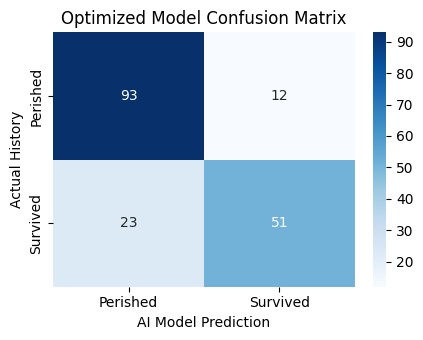

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report

df = pd.read_csv('titanic_passengers.csv')

plt.figure(figsize=(5, 3.5))
sns.countplot(x='Survived', data=df, palette='Set2')
plt.title('Target Variable Class Balance (Survived)')
plt.xlabel('Survived (0 = Perished, 1 = Survived)')
plt.ylabel('Passenger Count')
plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 3.5))
sns.countplot(x='Sex', hue='Survived', data=df, palette='pastel')
plt.title('Survival Count by Gender')
plt.xlabel('Gender')
plt.ylabel('Passenger Count')
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 3.5))
sns.histplot(df['Age'].dropna(), kde=True, color='skyblue', bins=30)
plt.title('Passenger Age Distribution')
plt.xlabel('Age')
plt.ylabel('Passenger Count')
plt.tight_layout()
plt.show()

df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = np.where(df['FamilySize'] == 1, 1, 0)

df_encoded = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)

X = df_encoded.drop(columns=['Survived', 'PassengerId', 'Name', 'Ticket', 'Cabin'])
y = df_encoded['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr_param_grid = {'C': [0.1, 1, 10, 100]}
lr_grid = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42), lr_param_grid, cv=5)
lr_grid.fit(X_train, y_train)

rf_param_grid = {'n_estimators': [50, 100], 'max_depth': [3, 5, None]}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_param_grid, cv=5)
rf_grid.fit(X_train, y_train)

print(f"Logistic Regression Best Grid Score: {lr_grid.best_score_:.2%}")
print(f"Random Forest Best Grid Score: {rf_grid.best_score_:.2%}")

best_model = lr_grid.best_estimator_ if lr_grid.best_score_ >= rf_grid.best_score_ else rf_grid.best_estimator_
print(f"\nSelected Best Estimator: {best_model}")

print(f"\nFinal Training Accuracy Score: {best_model.score(X_train, y_train):.2%}")
print(f"Final Testing Accuracy Score: {best_model.score(X_test, y_test):.2%}")

y_pred = best_model.predict(X_test)
print("\n--- Final Classification Report ---")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4.5, 3.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Perished', 'Survived'],
            yticklabels=['Perished', 'Survived'])
plt.title('Optimized Model Confusion Matrix')
plt.ylabel('Actual History')
plt.xlabel('AI Model Prediction')
plt.tight_layout()
plt.show()